# Creating Figures with data

In this Jupyter notebook we'll explore how to create figures from data using `matplotlib`.

# Dependencies

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# disable automatic figure display (plt.show() required)
# this ensures consistency with .py scripts
plt.ioff()

# Dependencies
To import matplotlib we use the code below. It is standard practice to call the matplotlib pyplot module `plt`. Following this standard makes your code easier for others to read.

In [ ]:
import matplotlib.pyplot as plt

# A simple plot

In [ ]:
time = [0, 1, 2, 3]
position = [0, 100, 200, 300]

# create a plot with time on the x-axis and position on the y-axis
plt.plot(time, position)

# x-axis label
plt.xlabel('Time (hr)')

# y-axis label
plt.ylabel('Position (km)')

# axis title
plt.title('My Very First Plot')
plt.show()

# Changing style

In [ ]:
# We can change the style our matplotlib figures quite alot using plt.style
# Have a look at https://tonysyu.github.io/raw_content/matplotlib-style-gallery/gallery.html for a full list
plt.style.use('ggplot')

# Other kinds of plots
In matplotlib you can create other kinds of plots such as bar charts, pie charts and histograms.

In [ ]:
# Data to plot
languages = ['Java', 'Python', 'PHP', 'JavaScript', 'C#', 'C++']
populatity = [22.2, 17.6, 8.8, 8, 7.7, 6.7]

# Plot a pie chart
plt.pie(populatity, labels=languages)
plt.show()

# Plot a bar chart
plt.bar(languages, populatity)
plt.show()

# Plot a histogram
x = np.random.randn(100000)
plt.hist(x, bins=50)
plt.show()

# Subplots

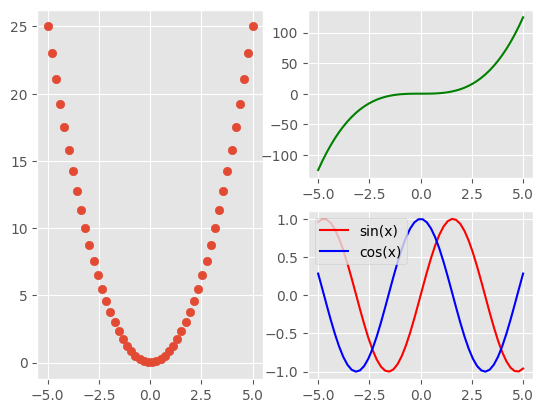

In [24]:
# a figure with one Axes on the left, and two on the right
fig, axes = plt.subplot_mosaic([["left", "right_top"], ["left", "right_bottom"]])

x = np.linspace(-5, 5, 50)

axes['left'].scatter(x, x**2)

axes['right_top'].plot(x, x**3, color='green')

axes['right_bottom'].plot(x, np.sin(x), color = 'red')
axes['right_bottom'].plot(x, np.cos(x), color = 'blue')
axes['right_bottom'].legend(['sin(x)', 'cos(x)'], loc='upper left')

plt.show()

# Save our masterpiece to a file
fig.savefig('my_figure.png')

# Your turn
Time for some practice.

In [ ]:
# Create the same plot as above but plot the inverse of each function. So for x^2 plot sqrt(x) and so on.
# Do some research to find out the numpy versions of these functions.
# Don't forget to label your axes!

# a figure with one Axes on the left, and two on the right
fig, axes = plt.subplot_mosaic([["left", "right_top"], ["left", "right_bottom"]])

x = np.linspace(-5, 5, 50)

axes['left'].scatter(x, np.sqrt(x))

axes['right_top'].plot(x, np.cbrt(x), color='green')

axes['right_bottom'].plot(x, np.arcsin(x), color = 'red')
axes['right_bottom'].plot(x, np.arccos(x), color = 'blue')
axes['right_bottom'].legend(['arcsin(x)', 'arccos(x)'], loc='upper left')

plt.show()

# Save our masterpiece to a file
fig.savefig('my_figure.png')

In [ ]:
# Based on a the data below create a bar chart comparing programming lanaguage popularity in 2020 vs 2026
# Make sure to add axis labels, a tile and a legend.
# EXTENSION: How can you plot the bars next to each other rather than stacked? Hint: Think about the width of a bar

languages = np.array(['Java', 'Python', 'PHP', 'JavaScript', 'C#', 'C++', 'Rust'])
populatity_2020 = np.array([22.2, 17.6, 7.6, 8, 7.7, 6.7, 1.2])
populatity_2026 = np.array([14.1, 20.2, 5.3, 8.2, 7.5, 6.5, 9.2])
x_values = np.arange(len(languages))

width = 0.2

plt.bar(x_values, populatity_2020, label='2020', width=0.2, tick_label=languages)
plt.bar(x_values+width, populatity_2026, label='2026', width=0.2, tick_label=languages)

# x-axis label
plt.xlabel('Language')

# y-axis label
plt.ylabel('Popularity (%)')

# axis title
plt.title('Programming Language Popularity 2020 vs 2026')

plt.legend()
plt.show()

# More interesting data

We will now use the same weather data from Monday. The code below creates a new dataframe and follows the same data cleaning steps from Monday. Make sure to upload the weather data csv to colab.

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("Weather-2021-Dataset.csv")

# Convert time to datetime
data['time'] = pd.to_datetime(data['time'])

# Drop any null values
data.dropna()

# Remove any duplicates
data.drop_duplicates()

# View the data
display(data)

# Plotting from a Dataframe


In [ ]:
# Get data just for London
London = data[data['location_id'] == 0]

time = London['time']
temperature = London['temperature']

# Create a plot with time on the x-axis and temperature on the y-axis
plt.plot(time, temperature)

# x-axis label
plt.xlabel('Time')

# y-axis label
plt.ylabel('Temperature (°C)')

# axis title
plt.title('Temperature in London')
plt.show()


# More Practice

Now that you have some data to play with, can you combine your Pandas and matplotlib knowledge to create the following figures. Remember google is your friend!

You can also use this [matplotlib cheatsheet](https://matplotlib.org/cheatsheets/cheatsheets.pdf) to help you.

[Pandas Cheatsheet](https://www.dataquest.io/cheat-sheet/pandas-cheat-sheet/) from Monday.

## Exercises


1.   Plot a bar chart of average temperature in each Month in London.
2. Plot a line graph showing the cumulative amount of precipitation over the year for each city.
3. Plot 3 overlapping histograms of the temperature in each city. How do the peaks of these bell curves compare? How do the peaks link to average temperature?
4. Investigate the correlation between temperature and humidity, how might you visualise this correlation? Do some research on Pandas and calculate the Pearson Correlation coefficent between these two fields. (Hint: it's one line). Are there any other strongly correlated fields? Does this align with what you might expect?
5. Make a pie chart showing the proportion of days it rained in Edinburgh.



Month
1      3.600000
2      5.295536
3      7.070027
4      6.621806
5     10.864919
6     16.898056
7     18.058737
8     16.539382
9     16.485556
10    12.492339
11     7.605417
12     7.150941
Name: temperature, dtype: float64


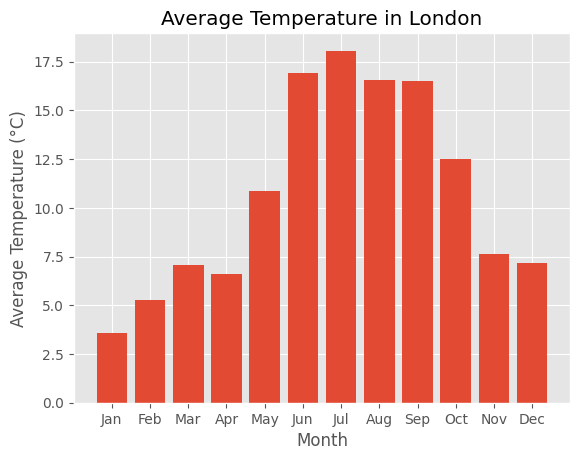

In [20]:
# Exercise 1 - Bar Chart of Mean Temp in London in each Month

# get london data
london = data[data['location_id'] == 0].copy()
# Create a field for Month
london["Month"] = london["time"].dt.month

# Group by month and get the mean temperature
mean_temp_month = london.groupby("Month")["temperature"].mean()

print(mean_temp_month)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.bar(month_labels, mean_temp_month)

# x-axis label
plt.xlabel('Month')

# y-axis label
plt.ylabel('Average Temperature (°C)')

# axis title
plt.title('Average Temperature in London')

plt.show()


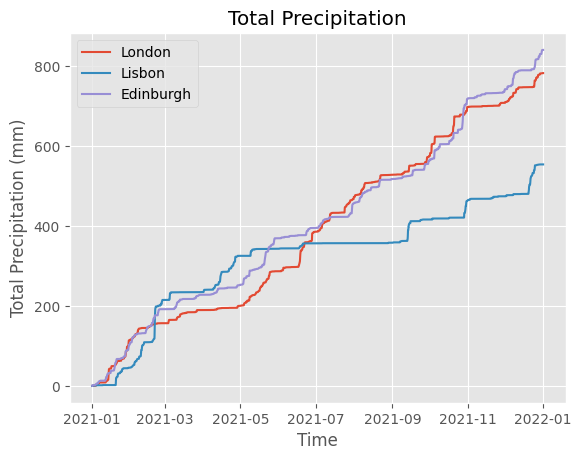

In [21]:
# Exercise 2
london = data[data["location_id"] == 0].copy()
london["cumulative_precipitation"] = london["precipitation"].cumsum()

edinburgh = data[data["location_id"] == 1].copy()
edinburgh["cumulative_precipitation"] = edinburgh["precipitation"].cumsum()

lisbon = data[data["location_id"] == 2].copy()
lisbon["cumulative_precipitation"] = lisbon["precipitation"].cumsum()

plt.plot(london["time"], london["cumulative_precipitation"], label="London")
plt.plot(lisbon["time"], lisbon["cumulative_precipitation"], label="Lisbon")
plt.plot(edinburgh["time"], edinburgh["cumulative_precipitation"], label="Edinburgh")

# x-axis label
plt.xlabel('Time')

# y-axis label
plt.ylabel('Total Precipitation (mm)')

# axis title
plt.title('Total Precipitation')

plt.legend()
plt.show()

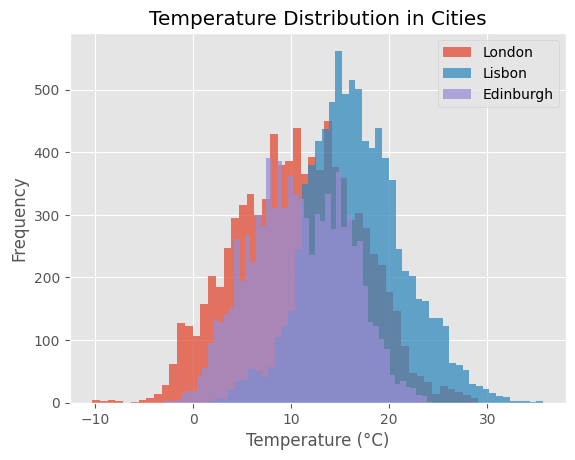

In [23]:
# Exercies 3 Histograms of temperature in each city
london = data[data["location_id"] == 0].copy()

edinburgh = data[data["location_id"] == 1].copy()

lisbon = data[data["location_id"] == 2].copy()
bins = 50
plt.hist(london["temperature"], bins=bins, label="London", alpha = 0.75)
plt.hist(lisbon["temperature"], bins=bins, label="Lisbon", alpha = 0.75)
plt.hist(edinburgh["temperature"], bins=bins, label="Edinburgh", alpha = 0.75)

plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Temperature Distribution in Cities")
plt.legend()
plt.show()


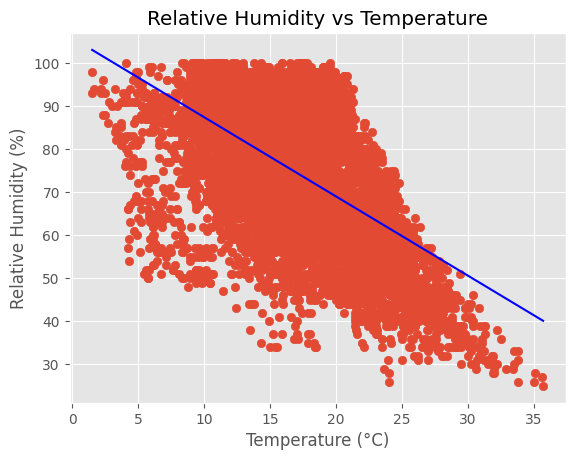

In [26]:
# Exercise 4
lisbon = data[data["location_id"] == 2].copy()

lisbon.corr()

plt.scatter(lisbon["temperature"], lisbon["relative_humidity"], label="Data")

#plot line of best fit
x = np.unique(lisbon["temperature"])
y = np.poly1d(np.polyfit(lisbon["temperature"], lisbon["relative_humidity"], 1))(np.unique(lisbon["temperature"]))
plt.plot(x, y, label = "best fit", color="blue")

plt.title("Relative Humidity vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")

plt.show()

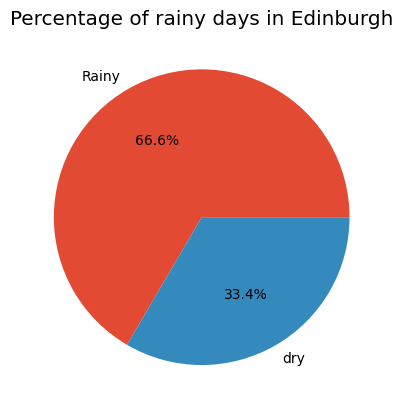

In [27]:
# Edinburgh
edinburgh = data[data["location_id"] == 1].copy()

#create a date column
edinburgh["date"] = edinburgh["time"].dt.date

# get total precipitation each day
total_daily_precipitation = edinburgh.groupby("date")["precipitation"].sum()
days_it_rained = len(total_daily_precipitation[total_daily_precipitation > 0])


percentage_rainy = (days_it_rained/365)*100
percentage_dry = 100-percentage_rainy
labels = ["Rainy", "dry"]

plt.pie([percentage_rainy, percentage_dry], labels=labels, autopct='%1.1f%%')

plt.title("Percentage of rainy days in Edinburgh")
plt.show()


## Extension
Matplotlib is not the only plotting library out there. If you have some time you should look into [Plotly](https://plotly.com/python/) and [Seaborn](https://seaborn.pydata.org/).
The use cases for each library are outlined below:
### Matplotlib
Low-level plotting foundation allows for highly customized plots with publication-quality figures for scientific and academic work.
### Seaborn
Fast exploratory data analysis (EDA) with statistical visualizations such as distributions, correlations, and regressions.
### Plotly
Interactive web-based charts with hover, zoom, and filtering capabilities.
